# Qual classificação climática serve melhor de base para estimar SOC e textura?

Comparação de classificações climáticas geradas a partir do CHELSA V2.1 (normal 1991-2020) —
**Köppen-Geiger**, **Holdridge** (ETP Penman e ETP de Holdridge), **Thornthwaite** (CAD de 100 mm e CAD do
solo) e **zonas climáticas homogêneas** (k-means, 10 zonas) — tendo o
**Köppen IPEF** (o que vem nas matrizes do MapBiomas Solo C3) como referência. Variáveis de solo na camada
de 0-30 cm: estoque de carbono orgânico (SOC) e as frações areia, silte e argila.

**O que este notebook responde:** qual classificação, **usada sozinha** (a estimativa de um local é a média da
sua classe), separa melhor o SOC e a textura. Para o uso do clima **dentro dos modelos de predição** do
MapBiomas, junto com as outras covariáveis, ver `experimento_clima_modelos.ipynb` e a reprodução em
`climas/reproducao/` — lá o melhor é o clima contínuo, e as zonas k10 vêm em segundo.

**Resposta curta** (detalhes nas seções 4 a 9):

- **As zonas climáticas homogêneas (k10) são a melhor classificação.** Nos blocos de 1° e 2° são as melhores
  nas quatro variáveis — SOC (R² 0,092), areia (0,106), silte (0,210) e argila (0,009, a única positiva) — e
  em SOC, areia e silte vencem todos os outros sistemas em todas as repetições. Com só 10 classes.
- **Longe das amostras (blocos de 5°)** continuam as melhores em silte; em SOC ficam um pouco atrás do
  Holdridge L2 (0,083 × 0,094) e, na areia, atrás do Köppen IPEF L1.
- **Entre as classificações clássicas:** Holdridge L2 (ETP de Holdridge) para SOC e Thornthwaite L2 para silte.
- **A CAD do BHC não importa:** CAD 100 mm e CAD do solo dão praticamente o mesmo resultado.
- **Köppen CHELSA fica abaixo do Köppen IPEF**, apesar de usar dados climáticos mais recentes. O motivo é
  localizado (seção 6): ~765 locais do Sudeste na fronteira tropical/subtropical.
- **Classe climática sozinha é uma base fraca:** nenhuma estima argila fora da amostra, e para SOC o teto é
  R² ≈ 0,10.

## 1. A pergunta certa: não é "correlação"

A pergunta — qual classificação climática serve melhor de base para estimar SOC e textura — pede três
ajustes antes de escolher uma métrica:

1. **Não é correlação no sentido estrito.** Clima em classes é uma variável nominal: Pearson e Spearman
   não se aplicam, e o ponto-bisserial mede uma classe de cada vez, não o sistema inteiro. O que dá para
   medir é **quanto da variação de SOC e textura cada classificação explica**.
2. **Os sistemas não têm o mesmo número de classes.** Aqui vão de 3 (Köppen L1) a 32 (Thornthwaite L3); as zonas k10 têm 10.
   Mais classes sempre explicam mais *dentro* da amostra, mesmo que não carreguem informação nenhuma. A
   métrica precisa penalizar isso — senão ganha quem tem mais classes.
3. **Com ~12 mil locais, qualquer teste dá p < 0,001.** Kruskal-Wallis e ANOVA seriam "significativos"
   para todos os sistemas e não ajudariam a escolher. Por isso não há p-valores nesta análise.

## 2. A métrica: R² fora da amostra, com validação em blocos espaciais

Cada classificação é usada como **único preditor**: a estimativa de um local é a **média da sua classe**,
calculada só com os locais de treino. Mede-se o R² nos locais de teste:

$$R^2 = 1 - \frac{\sum (y - \hat{y})^2}{\sum (y - \bar{y})^2}$$

Os locais de teste são separados em **blocos espaciais** (quadrículas de 2°, principal; 1° e 5° como
sensibilidade), sorteados em 5 dobras e repetidos 50 vezes. Por que essa métrica:

- **Mede exatamente o que se quer:** o quanto a classificação ajuda a estimar SOC e textura num lugar onde
  não há amostra.
- **Penaliza classes demais sozinha:** uma classe pequena ou sem informação tem média instável e piora o
  R² no teste. O R² fora da amostra pode até ficar **negativo** — significa que usar a média da classe
  estima *pior* do que usar a média geral do Brasil.
- **Os blocos espaciais evitam R² inflado:** locais vizinhos são parecidos (autocorrelação espacial); com
  dobras aleatórias, o teste sempre tem um vizinho no treino e o R² fica otimista.
- **Mesma escala e mesmas dobras para todos:** os sistemas são avaliados nos mesmos locais e nas mesmas
  dobras em cada repetição, então a diferença de R² entre dois sistemas é **pareada**. Dá para dizer se
  uma vantagem é consistente (aparece em quase todas as repetições) ou é ruído do sorteio dos blocos.

Complemento descritivo: **ω² (ômega-quadrado)**, o tamanho de efeito da ANOVA de um fator — a fração da
variância explicada pelas classes *dentro da amostra*, já descontado o ganho que se teria só por haver k
classes (ao contrário do η², que sempre cresce com k).

**Como ler:** R² espacial é a métrica de decisão; ω² descreve a associação. SOC entra como **log(SOC)**,
porque o estoque é muito assimétrico; as frações de textura, em %.

In [1]:
from pathlib import Path
import os

# Roda de dentro da pasta corelacao/ mesmo que o kernel tenha começado na pasta pai.
if not Path('resultados/tabelas').exists() and Path('corelacao/resultados/tabelas').exists():
    os.chdir('corelacao')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
TAB = Path('resultados/tabelas')
amostra = pd.read_csv(TAB / 'amostra.csv')
desemp = pd.read_csv(TAB / 'desempenho.csv')
difs = pd.read_csv(TAB / 'diferencas_pareadas.csv')
classes = pd.read_csv(TAB / 'classes.csv')

RESPOSTAS = {'log_soc': 'log(SOC)', 'argila': 'Argila (%)', 'areia': 'Areia (%)', 'silte': 'Silte (%)'}
SISTEMAS = ['Köppen IPEF (referência)', 'Köppen CHELSA', 'Holdridge ETP Penman', 'Holdridge ETP Holdridge',
            'Thornthwaite CAD 100 mm', 'Thornthwaite CAD do solo', 'Zonas climáticas k10']
CORES = {'Köppen IPEF (referência)': '#8c8c8c', 'Köppen CHELSA': '#2a78d6', 'Holdridge ETP Penman': '#eb6834',
         'Holdridge ETP Holdridge': '#4a3aa7', 'Thornthwaite CAD 100 mm': '#1baf7a',
         'Thornthwaite CAD do solo': '#eda100', 'Zonas climáticas k10': '#e87ba4'}
TINTA, TINTA2, GRADE = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({'font.size': 10, 'axes.edgecolor': TINTA2, 'axes.labelcolor': TINTA,
                     'xtick.color': TINTA2, 'ytick.color': TINTA2, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.facecolor': 'white'})

## 3. Dados e sistemas comparados

**Locais:** duas matrizes de pontos do MapBiomas Solo C3 (acesso restrito), limpas e agregadas por local
(uma linha por coordenada; pseudoamostras e amostras artificiais excluídas; textura só em 0-30 cm e com as
frações fechando 100%). Um local só entra se tiver classe em **todos** os sistemas e níveis — os ~1% que
ficam de fora estão no litoral ou em corpos d'água, onde algum raster CHELSA ou o AWC não tem valor.

In [2]:
display(amostra.rename(columns={'locais': 'locais na amostra comum',
                                 'excluidos_sem_classe': 'sem classe em algum sistema'}))

niveis = (desemp[desemp.resposta == 'log_soc'][['sistema', 'nivel', 'descricao', 'n_classes']]
          .rename(columns={'n_classes': 'classes presentes (SOC)'}))
display(niveis.reset_index(drop=True))

,resposta,rotulo,locais na amostra comum,sem classe em algum sistema,blocos_bloco_1,blocos_bloco_2,blocos_bloco_5,pct_regiao_rondonia,pct_rio_grande_do_sul,pct_20_blocos_2_mais_densos
0,log_soc,log(SOC),12207,79,651,200,44,25.714754,19.079217,55.902351
1,argila,Argila (%),11978,84,637,197,44,27.049591,18.675906,59.651027
2,areia,Areia (%),11978,84,637,197,44,27.049591,18.675906,59.651027
3,silte,Silte (%),11978,84,637,197,44,27.049591,18.675906,59.651027


,sistema,nivel,descricao,classes presentes (SOC)
0,Köppen IPEF (referência),L1,"grupo (A, B, C)",3
1,Köppen IPEF (referência),L2,"tipo (Af, Am, Aw, Cf...)",8
2,Köppen IPEF (referência),L3,"subtipo (Cfa, Cfb...)",10
3,Köppen CHELSA,L1,"grupo (A, B, C)",3
4,Köppen CHELSA,L2,"tipo (Af, Am, Aw, Cf...)",8
5,Köppen CHELSA,L3,"classe completa (Aw, Cfa...)",10
6,Holdridge ETP Penman,L1,faixa térmica (igual nas duas ETPs),4
7,Holdridge ETP Penman,L2,zona de vida,15
8,Holdridge ETP Holdridge,L2,zona de vida,13
9,Thornthwaite CAD 100 mm,L1,classe de umidade,9


- **Köppen IPEF (referência):** o que vem nas matrizes, como dummies. No L3, os locais do grupo A
  recebem o próprio tipo (Af, Am, As, Aw), que já é a classe completa — assim o L3 do IPEF equivale ao L3
  do Köppen CHELSA.
- **Köppen CHELSA:** classificação de Alvares et al. (2013) sobre a normal CHELSA, com a sazonalidade
  f/s/w dos climas C pelo critério de Kottek et al. (2006) e as estações trocadas ao norte do equador.
- **Holdridge CHELSA:** L1 = faixa térmica (biotemperatura), L2 = zona de vida, com a numeração e os nomes
  das 38 zonas de Jungkunst et al. (2021), base Leemans (1990). Duas versões da ETP na razão ETP/P, que
  define a província de umidade: **ETP Penman** (Penman-Monteith do CHELSA) e **ETP Holdridge**
  (58,93 × biotemperatura, a definição original, usada por Leemans e pelo artigo). A biotemperatura não
  depende da ETP, então o L1 é o mesmo nas duas e aparece uma vez só.
- **Thornthwaite CHELSA:** L1 = classe de umidade (A a E), L2 = + subtipo (r, s, w, d...), L3 = tipo
  completo. Com ETP de Penman-Monteith, quase todo o Brasil é A'a' nas duas últimas letras; por isso L3
  quase não difere de L2.
- **Zonas climáticas k10:** 10 zonas obtidas por k-means sobre 9 variáveis climáticas (temperatura média e
  do mês mais frio, chuva anual e do mês mais seco, sazonalidade da chuva, ETP, DEF, EXC e Im), ajustadas
  nos **pixels do Brasil** — sem usar SOC nem textura, então não há vazamento. Mapa e descrição em
  `experimento_clima_modelos.ipynb`.

## 4. Resultado principal: R² espacial de cada sistema

Cada ponto é o R² médio fora da amostra (blocos de 2°) e a barra, o intervalo de 95% entre as 50
repetições do sorteio dos blocos. A linha tracejada marca o melhor preditor de cada variável.

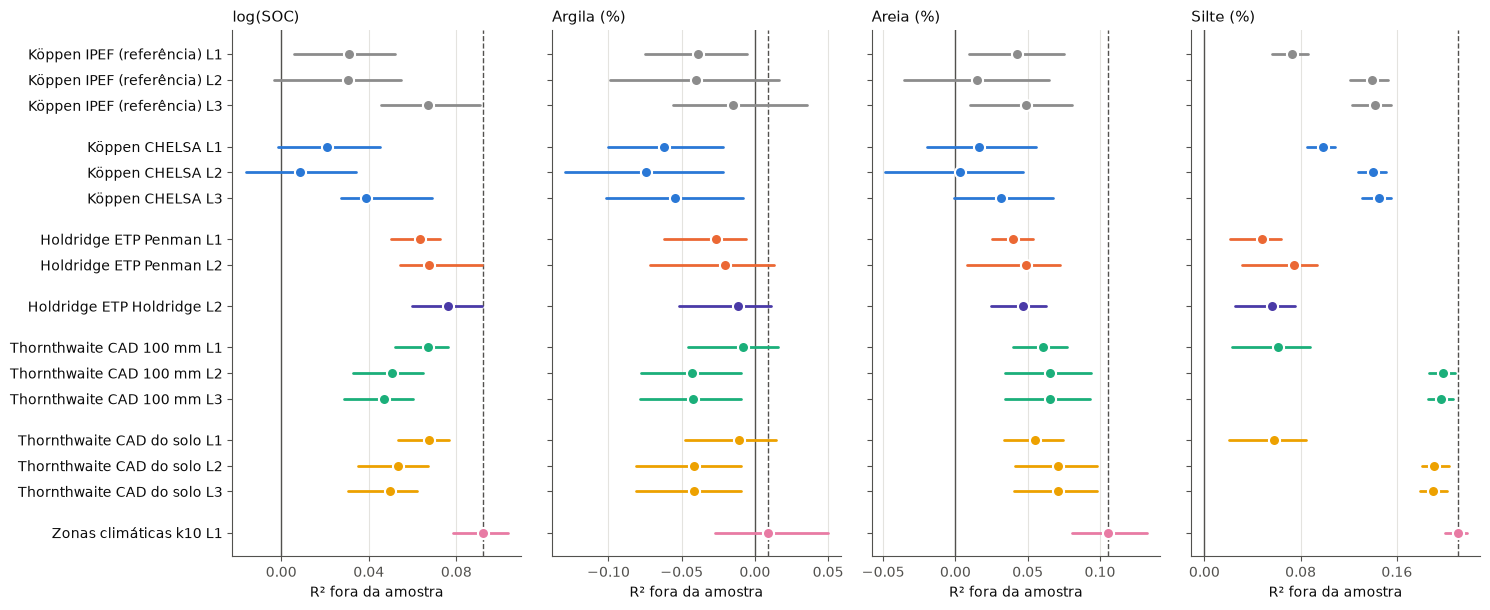

In [3]:
def grafico_r2(esquema='bloco_2'):
    fig, axes = plt.subplots(1, 4, figsize=(15, 6.2), sharey=True)
    ordem = [(s, n) for s in SISTEMAS for n in ('L1', 'L2', 'L3')
             if ((desemp.sistema == s) & (desemp.nivel == n)).any()]
    ypos, y, ult = {}, 0, None
    for s, n in ordem:                       # espaço extra entre sistemas
        y += 1.6 if (ult and ult != s) else 1.0
        ypos[(s, n)] = y
        ult = s
    for ax, (resp, rotulo) in zip(axes, RESPOSTAS.items()):
        d = desemp[desemp.resposta == resp]
        ax.axvline(0, color=TINTA2, lw=1)
        ax.axvline(d[f'r2_{esquema}'].max(), color=TINTA2, lw=1, ls='--')
        for r in d.itertuples():
            yy = ypos[(r.sistema, r.nivel)]
            lo, hi = getattr(r, f'r2_{esquema}_ic_inf'), getattr(r, f'r2_{esquema}_ic_sup')
            ax.plot([lo, hi], [yy, yy], color=CORES[r.sistema], lw=2, solid_capstyle='round')
            ax.plot(getattr(r, f'r2_{esquema}'), yy, 'o', ms=8, color=CORES[r.sistema],
                    markeredgecolor='white', markeredgewidth=1.5)
        ax.set_title(rotulo, color=TINTA, fontsize=11, loc='left')
        ax.grid(axis='x', color=GRADE, lw=0.8)
        ax.set_xlabel('R² fora da amostra')
        ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    axes[0].set_yticks(list(ypos.values()))
    axes[0].set_yticklabels([f'{s} {n}' for s, n in ypos])
    axes[0].invert_yaxis()
    for lbl, (s, _) in zip(axes[0].get_yticklabels(), ypos):
        lbl.set_color(TINTA)
    fig.tight_layout()
    return fig

grafico_r2('bloco_2');
plt.show()

In [4]:
tabela = desemp.pivot_table(index=['sistema', 'nivel', 'n_classes'], columns='resposta',
                            values='r2_bloco_2', sort=False)[list(RESPOSTAS)]
tabela.columns = [f'R² {RESPOSTAS[c]}' for c in tabela.columns]
display(tabela.round(3))

R² log(SOC)  R² Argila (%)  R² Areia (%)  R² Silte (%)
sistema                  nivel n_classes                                                        
Köppen IPEF (referência) L1    3                0.031         -0.039         0.042         0.073
                         L2    8                0.031         -0.040         0.015         0.140
                         L3    10               0.067         -0.015         0.049         0.142
Köppen CHELSA            L1    3                0.021         -0.062         0.016         0.098
                         L2    8                0.009         -0.074         0.003         0.141
                         L3    10               0.039         -0.055         0.032         0.145
Holdridge ETP Penman     L1    4                0.063         -0.027         0.040         0.048
                         L2    15               0.068         -0.020         0.049         0.075
Holdridge ETP Holdridge  L2    13               0.076         -0.011         0.047         0.056
Thornthwaite CAD 100 mm  L1    9                0.067         -0.008         0.060         0.061
                         L2    26               0.051         -0.043         0.066         0.199
                         L3    32               0.047         -0.042         0.065         0.197
Thornthwaite CAD do solo L1    9                0.068         -0.011         0.055         0.058
                         L2    26               0.054         -0.042         0.071         0.191
                         L3    32               0.050         -0.041         0.071         0.190
Zonas climáticas k10     L1    10               0.092          0.009         0.106         0.210

**Leitura, variável por variável:**

- **log(SOC):** todos explicam pouco — o melhor, as **zonas k10**, chega a R² ≈ 0,09 (cerca de 9% da variação
  do carbono entre locais que o modelo nunca viu). Entre as classificações clássicas, Holdridge L2 (ETP de
  Holdridge, 0,076), Thornthwaite L1 e Köppen IPEF L3 (≈ 0,07) ficam praticamente empatados. Köppen CHELSA
  fica abaixo em todos os níveis.
- **Argila:** **nenhum sistema estima argila** fora da amostra: todos ficam com R² ≈ 0 ou negativo (as zonas
  k10, com 0,009, são as únicas acima de zero). Dentro da amostra há alguma associação (ω² de 0,02 a 0,11,
  seção 8), mas ela não se transfere para regiões novas. A argila depende sobretudo do material de origem e
  do relevo, que o clima atual não captura.
- **Areia:** as **zonas k10** (0,106) ficam bem à frente de todos; entre as clássicas, o Thornthwaite L2
  lidera (0,071).
- **Silte:** a variável em que o clima mais explica. **Zonas k10** (0,210) e **Thornthwaite L2** (≈ 0,20) ficam
  à frente de todos os Köppen (≤ 0,15) e do Holdridge (≤ 0,08). No Thornthwaite, é o subtipo — em que estação
  falta ou sobra água — que faz a diferença: o L1 sozinho cai para 0,06.

**Por que as zonas k10 funcionam melhor:** as classificações clássicas foram desenhadas para vegetação e
usam limiares fixos de temperatura ou de razão ETP/P; as zonas agrupam o Brasil pelas combinações de
temperatura, chuva, sazonalidade e balanço hídrico que de fato ocorrem no país, com fronteiras onde o clima
muda de verdade.

Em todas as variáveis, **CAD 100 mm e CAD do solo ficam praticamente sobrepostas.** É esperado: no
equilíbrio anual do balanço hídrico, excedente − deficiência = P − ETP, qualquer que seja a CAD; ela só
redistribui água entre os dois, e a classificação quase não muda.

**E a ETP do Holdridge?** Ela muda a classificação bem mais que a CAD (~23% da área do Brasil troca de zona;
com a ETP de Holdridge o país fica mais úmido, sobretudo no Sul e Sudeste), mas quase não muda o
desempenho:

| log(SOC), R² espacial | blocos 1° | blocos 2° | blocos 5° |
|---|---|---|---|
| Holdridge L2, ETP Holdridge | 0,082 | 0,076 | 0,093 |
| Holdridge L2, ETP Penman | 0,080 | 0,068 | 0,094 |

Para SOC, a ETP de Holdridge é igual ou um pouco melhor em todas as escalas; para silte, a ETP Penman é
melhor (0,075 × 0,056), mas as duas ficam muito atrás do Thornthwaite L2 e das zonas k10. Como a ETP de
Holdridge é a definição original — e a que permite comparar com Jungkunst et al. (2021) —, é a recomendada
quando se usar o Holdridge.

## 5. As diferenças são reais? Comparação pareada com o melhor

Para cada variável, a tabela mostra quanto o melhor preditor supera cada um dos outros (ΔR², blocos de
2°), com o intervalo de 95% entre as repetições e a proporção de repetições em que o melhor venceu.
**Se o intervalo inclui zero, os dois estão empatados** — a diferença cabe no ruído do sorteio dos blocos.

In [5]:
def empates(resp):
    d = difs[difs.resposta == resp].copy()
    d['empatado'] = d.ic_inf <= 0
    d = d[d.coluna != d.melhor].sort_values('delta_r2')
    return d[['sistema', 'nivel', 'delta_r2', 'ic_inf', 'ic_sup', 'prop_melhor_vence', 'empatado']]

for resp, rotulo in RESPOSTAS.items():
    m = difs[difs.resposta == resp].melhor.iloc[0]
    s, n = desemp.loc[desemp.coluna == m, ['sistema', 'nivel']].iloc[0]
    print(f'{rotulo}: melhor = {s} {n}')
    display(empates(resp).round(3).reset_index(drop=True))

log(SOC): melhor = Zonas climáticas k10 L1


,sistema,nivel,delta_r2,ic_inf,ic_sup,prop_melhor_vence,empatado
0,Holdridge ETP Holdridge,L2,0.016,0.002,0.030,1.0,False
1,Thornthwaite CAD do solo,L1,0.024,0.013,0.038,1.0,False
2,Holdridge ETP Penman,L2,0.025,0.003,0.044,1.0,False
3,Thornthwaite CAD 100 mm,L1,0.025,0.013,0.038,1.0,False
4,Köppen IPEF (referência),L3,0.025,0.005,0.041,1.0,False
5,Holdridge ETP Penman,L1,0.029,0.016,0.043,1.0,False
6,Thornthwaite CAD do solo,L2,0.039,0.026,0.051,1.0,False
7,Thornthwaite CAD 100 mm,L2,0.041,0.030,0.056,1.0,False
8,Thornthwaite CAD do solo,L3,0.043,0.029,0.056,1.0,False
9,Thornthwaite CAD 100 mm,L3,0.045,0.034,0.061,1.0,False


Argila (%): melhor = Zonas climáticas k10 L1


,sistema,nivel,delta_r2,ic_inf,ic_sup,prop_melhor_vence,empatado
0,Thornthwaite CAD 100 mm,L1,0.017,-0.032,0.074,0.70,True
1,Thornthwaite CAD do solo,L1,0.020,-0.033,0.072,0.76,True
2,Holdridge ETP Holdridge,L2,0.020,-0.027,0.078,0.74,True
3,Köppen IPEF (referência),L3,0.024,-0.030,0.067,0.78,True
4,Holdridge ETP Penman,L2,0.029,-0.023,0.102,0.82,True
5,Holdridge ETP Penman,L1,0.035,-0.011,0.084,0.88,True
6,Köppen IPEF (referência),L1,0.047,-0.001,0.083,0.96,True
7,Köppen IPEF (referência),L2,0.049,-0.026,0.093,0.94,True
8,Thornthwaite CAD do solo,L3,0.050,0.024,0.094,1.00,False
9,Thornthwaite CAD do solo,L2,0.050,0.024,0.094,1.00,False


Areia (%): melhor = Zonas climáticas k10 L1


,sistema,nivel,delta_r2,ic_inf,ic_sup,prop_melhor_vence,empatado
0,Thornthwaite CAD do solo,L2,0.035,0.015,0.067,1.0,False
1,Thornthwaite CAD do solo,L3,0.035,0.015,0.068,1.0,False
2,Thornthwaite CAD 100 mm,L2,0.040,0.020,0.077,1.0,False
3,Thornthwaite CAD 100 mm,L3,0.040,0.020,0.077,1.0,False
4,Thornthwaite CAD 100 mm,L1,0.045,0.009,0.079,1.0,False
5,Thornthwaite CAD do solo,L1,0.051,0.011,0.083,1.0,False
6,Holdridge ETP Penman,L2,0.057,0.021,0.122,1.0,False
7,Köppen IPEF (referência),L3,0.057,0.014,0.090,1.0,False
8,Holdridge ETP Holdridge,L2,0.059,0.024,0.101,1.0,False
9,Köppen IPEF (referência),L1,0.064,0.022,0.095,1.0,False


Silte (%): melhor = Zonas climáticas k10 L1


,sistema,nivel,delta_r2,ic_inf,ic_sup,prop_melhor_vence,empatado
0,Thornthwaite CAD 100 mm,L2,0.012,0.001,0.023,1.0,False
1,Thornthwaite CAD 100 mm,L3,0.014,0.003,0.024,1.0,False
2,Thornthwaite CAD do solo,L2,0.019,0.008,0.030,1.0,False
3,Thornthwaite CAD do solo,L3,0.021,0.010,0.032,1.0,False
4,Köppen CHELSA,L3,0.065,0.055,0.081,1.0,False
5,Köppen IPEF (referência),L3,0.069,0.057,0.089,1.0,False
6,Köppen CHELSA,L2,0.070,0.057,0.084,1.0,False
7,Köppen IPEF (referência),L2,0.071,0.060,0.090,1.0,False
8,Köppen CHELSA,L1,0.112,0.103,0.126,1.0,False
9,Holdridge ETP Penman,L2,0.136,0.116,0.176,1.0,False


**Leitura:**

- **SOC, areia e silte:** as zonas k10 vencem **todos** os outros sistemas em **todas** as repetições
  (intervalos acima de zero). A vantagem não é ruído do sorteio dos blocos.
- **Argila:** vários "empates", mas eles são empates em torno de zero: nenhum sistema tem R² espacial
  positivo com segurança. Não há sistema melhor para argila; há só sistemas menos ruins.

## 6. Por que o Köppen CHELSA fica abaixo do Köppen IPEF

Os dois são o mesmo sistema (Köppen-Geiger, critérios de Alvares et al. 2013), mas o IPEF usa normais
climáticas mais antigas, interpoladas a 100 m com regressão pela altitude, e o CHELSA usa a normal
1991-2020 a ~1 km. Nos mesmos locais, eles concordam pouco:

In [6]:
conc = pd.read_csv(TAB / 'koppen_concordancia.csv').query("resposta == 'log_soc'")
print(f"Mesma classe (L3) nos dois: {100 * conc[conc.ipef_l3 == conc.chelsa_l3].n.sum() / conc.n.sum():.1f}% dos locais de SOC")
display(conc.pivot_table(index='ipef_l3', columns='chelsa_l3', values='n', fill_value=0, aggfunc='sum')
        .rename_axis(index='IPEF', columns='CHELSA'))

Mesma classe (L3) nos dois: 55.7% dos locais de SOC


CHELSA,Af,Am,As,Aw,BSh,BWh,Cfa,Cfb,Cwa,Cwb
IPEF,,,,,,,,,,
Af,328,140,2,15,0,0,0,0,0,0
Am,14,878,58,3213,0,0,0,0,0,0
As,0,0,260,481,119,0,0,0,0,0
Aw,1,24,1,1660,27,0,0,0,0,0
BSh,0,0,7,84,343,26,0,0,0,0
Cfa,56,62,0,99,1,0,2329,22,21,0
Cfb,0,1,0,1,0,0,149,792,17,10
Csa,0,0,1,0,0,0,0,0,0,0
Cwa,0,2,0,374,2,0,2,0,23,0


As duas maiores discordâncias:

- **Am (IPEF) → Aw (CHELSA):** ~3.200 locais, quase todos na região de Rondônia. A fronteira Am/Aw depende
  da chuva do mês mais seco.
- **Cfa/Cwa/Cwb (IPEF) → Aw/Af/Am (CHELSA):** ~765 locais no Sudeste (SP, sul e Triângulo Mineiro). O
  IPEF diz subtropical (C), o CHELSA diz tropical (A).

**Qual das duas custa o R²?** Para descobrir, montamos versões híbridas: o Köppen CHELSA com *uma* das
discordâncias trocada pela resposta do IPEF.

In [7]:
hib = pd.read_csv(TAB / 'koppen_hibridos.csv')
t = hib.pivot_table(index='versao', columns='resposta', values='r2_bloco_2', sort=False)[list(RESPOSTAS)]
t.columns = [f'R² {RESPOSTAS[c]}' for c in t.columns]
display(t.round(3))

,R² log(SOC),R² Argila (%),R² Areia (%),R² Silte (%)
versao,,,,
Köppen IPEF L3,0.067,-0.015,0.049,0.142
Köppen CHELSA L3,0.039,-0.055,0.032,0.145
CHELSA com o grupo do IPEF onde discordam (A x C/B),0.065,-0.027,0.062,0.140
CHELSA com o subtipo do IPEF dentro do grupo A (Am/Aw...),0.051,-0.054,0.020,0.155


Trocar só o **grupo** onde os dois discordam entre A e C/B basta para o CHELSA alcançar o IPEF em SOC
(0,039 → 0,065) e em areia (0,032 → 0,062). Trocar o subtipo Am/Aw de Rondônia não ajuda. **Toda a
diferença vem dos ~765 locais do Sudeste que o CHELSA põe no grupo A.** Em silte, os dois já empatavam.

**Por que esses locais mudam de grupo?** O critério do grupo A é a temperatura do mês mais frio ≥ 18 °C.
A tabela abaixo mostra essa temperatura, segundo o CHELSA, nos três grupos de locais:

In [8]:
fr = pd.read_csv(TAB / 'koppen_fronteira.csv').query("resposta == 'log_soc'")
fr = fr.rename(columns={'mediana_resposta': 'SOC mediano (Mg/ha)', 'tfrio_p10': 'T mês frio p10',
                        'tfrio_p50': 'T mês frio mediana', 'tfrio_p90': 'T mês frio p90',
                        'pct_tfrio_18_19': '% entre 18 e 19 °C'})
display(fr[['grupo', 'n', 'T mês frio p10', 'T mês frio mediana', 'T mês frio p90',
            '% entre 18 e 19 °C', 'SOC mediano (Mg/ha)']].round(1).reset_index(drop=True))

,grupo,n,T mês frio p10,T mês frio mediana,T mês frio p90,% entre 18 e 19 °C,SOC mediano (Mg/ha)
0,"IPEF C, CHELSA A",765,18.2,18.9,20.0,54.6,44.8
1,"IPEF C, CHELSA C",3758,11.9,13.5,17.1,0.0,49.5
2,"IPEF A, CHELSA A",7075,21.3,24.6,25.9,0.1,36.2


**Leitura:**

- Os locais que mudam de grupo estão **exatamente na fronteira**: o mês mais frio fica entre 18,2 e 20 °C
  no CHELSA, e metade deles entre 18 e 19 °C. Basta o CHELSA ser um pouco mais quente para cruzarem o
  limite.
- O **solo desses locais é de clima C**: SOC mediano de ≈ 45 Mg/ha, perto dos locais que os dois chamam
  de C (≈ 50 Mg/ha) e longe dos tropicais (≈ 36 Mg/ha). Ao pô-los em Aw, o CHELSA mistura solos mais ricos
  em carbono de planaltos mais frios com os tropicais e dilui as duas classes.
- **Não é erro de método:** o critério do grupo A está correto nos dois. A diferença vem dos dados. Há duas
  explicações prováveis, que não dá para separar sem as temperaturas do IPEF: o **período** (1991-2020 é
  mais quente que as normais antigas do IPEF) e a **resolução** (a regressão com altitude a 100 m do IPEF
  capta melhor o frio dos planaltos).
- **Interpretação:** o solo integra o clima de séculos a milênios, não o de 1991-2020. Onde uma
  classificação recente desloca uma fronteira por pouco, o solo continua com a assinatura do clima
  anterior. Isso não diz que o CHELSA está errado como clima atual; diz que, **para solo**, uma fronteira
  climática recente e deslocada pesa contra.

## 7. Por que validar em blocos: o R² cai quando o teste fica longe do treino

O gráfico mostra, para o melhor nível de cada sistema, o R² em cada esquema de validação: dobras
aleatórias (locais vizinhos podem estar um no treino e outro no teste) e blocos de 1°, 2° e 5°.

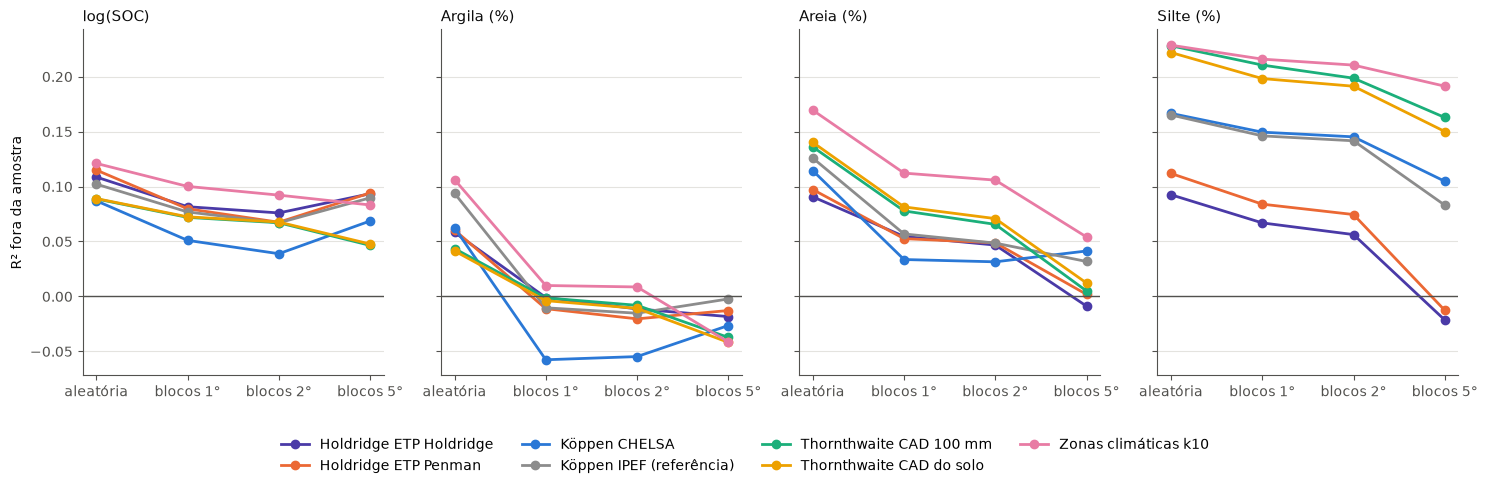

In [9]:
ESQUEMAS = {'aleatoria': 'aleatória', 'bloco_1': 'blocos 1°', 'bloco_2': 'blocos 2°', 'bloco_5': 'blocos 5°'}
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), sharey=True)
for ax, (resp, rotulo) in zip(axes, RESPOSTAS.items()):
    d = desemp[desemp.resposta == resp]
    melhores = d.loc[d.groupby('sistema').r2_bloco_2.idxmax()]
    for r in melhores.itertuples():
        vals = [getattr(r, f'r2_{e}') for e in ESQUEMAS]
        ax.plot(range(4), vals, '-o', color=CORES[r.sistema], lw=2, ms=6,
                label=f'{r.sistema} {r.nivel}')
    ax.axhline(0, color=TINTA2, lw=1)
    ax.set_xticks(range(4), list(ESQUEMAS.values()))
    ax.set_title(rotulo, color=TINTA, fontsize=11, loc='left')
    ax.grid(axis='y', color=GRADE, lw=0.8)
axes[0].set_ylabel('R² fora da amostra')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, [l.split(' L')[0] for l in labels], loc='lower center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.17))
fig.tight_layout()
plt.show()

**Leitura:**

- Com dobras **aleatórias**, o R² é praticamente igual ao ω² dentro da amostra — o teste sempre tem um
  vizinho no treino, e o resultado é otimista. Em argila, por exemplo, todos parecem explicar 2-11%, o que
  desaparece nos blocos.
- **Silte:** as zonas k10 lideram em todos os esquemas, inclusive nos blocos de 5° (≈ 0,19), com o
  Thornthwaite L2 logo atrás (≈ 0,16) e o Köppen em ≈ 0,11.
- **SOC:** a ordem muda com a distância. Nos blocos de 1° e 2° as zonas k10 lideram; nos de **5°** o
  **Holdridge L2 sobe para ≈ 0,09** (nas duas ETPs), o Köppen IPEF L3 também fica em ≈ 0,09, as zonas k10
  ficam logo atrás (≈ 0,08) e o Thornthwaite L1 cai para ≈ 0,05. Para estimar SOC muito longe das amostras,
  Holdridge e zonas k10 são os mais robustos.
- **Areia:** as zonas k10 lideram a 1° e 2°; a 5° o sinal fica fraco para todos, com o Köppen IPEF L1
  (≈ 0,06) e as zonas k10 (≈ 0,05) na frente.
- Os blocos de 5° têm só ~44 blocos, então esse esquema é mais ruidoso; ele serve como teste de robustez,
  não como métrica principal.

## 8. O que as classes mostram

Mediana de SOC e de silte por classe de umidade de Thornthwaite (CAD 100 mm, L1), da mais úmida (A) para
a mais seca (E). É a parte interpretável do resultado: o que a classe "sabe" sobre o solo.

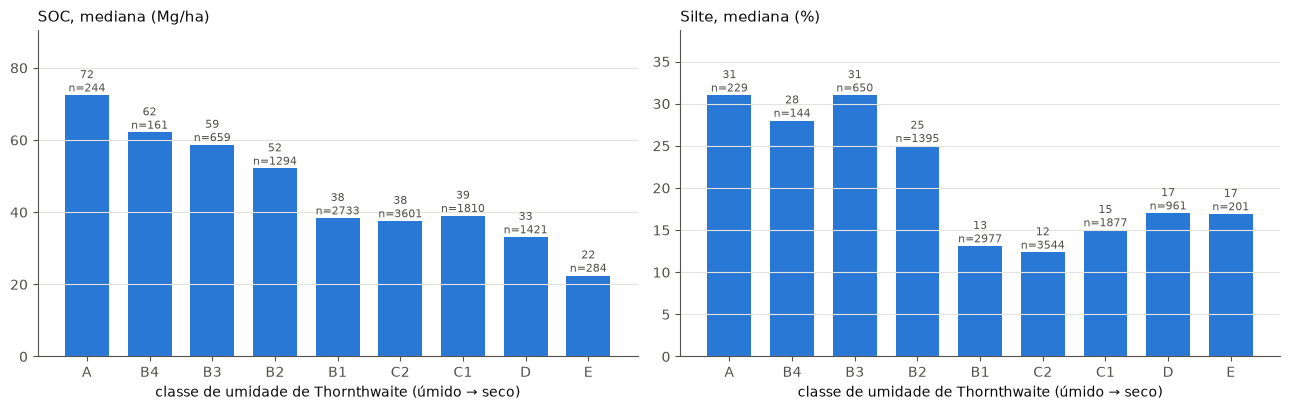

ω² log(SOC)  ω² Argila (%)  ω² Areia (%)  ω² Silte (%)
sistema                  nivel                                                        
Köppen IPEF (referência) L1           0.059          0.033         0.087         0.089
                         L2           0.070          0.061         0.095         0.162
                         L3           0.103          0.095         0.127         0.166
Köppen CHELSA            L1           0.057          0.021         0.075         0.112
                         L2           0.060          0.034         0.088         0.163
                         L3           0.088          0.063         0.115         0.168
Holdridge ETP Penman     L1           0.083          0.024         0.071         0.076
                         L2           0.117          0.061         0.098         0.113
Holdridge ETP Holdridge  L2           0.109          0.059         0.091         0.094
Thornthwaite CAD 100 mm  L1           0.090          0.044         0.094         0.106
                         L2           0.096          0.066         0.138         0.231
                         L3           0.096          0.068         0.139         0.230
Thornthwaite CAD do solo L1           0.090          0.042         0.089         0.103
                         L2           0.095          0.067         0.142         0.224
                         L3           0.095          0.068         0.143         0.224
Zonas climáticas k10     L1           0.122          0.107         0.170         0.230

In [10]:
ORDEM_UMIDADE = ['A', 'B4', 'B3', 'B2', 'B1', 'C2', 'C1', 'D', 'E']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, (resp, rotulo) in zip(axes, [('log_soc', 'SOC, mediana (Mg/ha)'), ('silte', 'Silte, mediana (%)')]):
    d = (classes[(classes.resposta == resp) & (classes.coluna == 'th100_l1')]
         .set_index('classe').reindex(ORDEM_UMIDADE).dropna(subset=['n']))
    x = np.arange(len(d))
    ax.bar(x, d.mediana, width=0.7, color='#2a78d6')
    for xi, (med, n) in enumerate(zip(d.mediana, d.n)):
        ax.text(xi, med, f'{med:.0f}\nn={int(n)}', ha='center', va='bottom', fontsize=8, color=TINTA2)
    ax.set_xticks(x, d.index)
    ax.set_title(rotulo, color=TINTA, fontsize=11, loc='left')
    ax.set_xlabel('classe de umidade de Thornthwaite (úmido → seco)')
    ax.grid(axis='y', color=GRADE, lw=0.8)
    ax.set_ylim(0, d.mediana.max() * 1.25)
fig.tight_layout()
plt.show()

omega = desemp.pivot_table(index=['sistema', 'nivel'], columns='resposta', values='omega2', sort=False)[list(RESPOSTAS)]
omega.columns = [f'ω² {RESPOSTAS[c]}' for c in omega.columns]
display(omega.round(3))

**Leitura:** o SOC cai do clima mais úmido para o mais seco — de ≈ 72 Mg/ha na classe A para ≈ 22 Mg/ha
na E, com um patamar em ≈ 38 Mg/ha entre B1 e C1. É o gradiente de umidade que a classificação de
Thornthwaite organiza diretamente. O silte separa dois grupos: climas úmidos (A a B2, ≈ 25-31%) e os
demais (≈ 12-17%); o subtipo (L2, a estação em que falta ou sobra água) refina essa separação, e é por
isso que o L2 é o melhor preditor de silte.

Na tabela de ω² (dentro da amostra), os valores são maiores que os R² espaciais — exatamente o otimismo
que a validação em blocos corrige. Serve para descrever a associação, não para escolher o sistema.

**As zonas k10:** mediana de SOC e das frações por zona (zonas numeradas da mais quente, 1, para a mais
fria, 10; descrição climática de cada uma em `experimento_clima_modelos.ipynb`).

In [11]:
z = classes[classes.coluna == 'zona_k10'].pivot_table(index='classe', columns='resposta', values='mediana')
z.index = z.index.astype(int); z = z.sort_index()
z = z.rename(columns={'log_soc': 'SOC (Mg/ha)', 'areia': 'Areia (%)', 'silte': 'Silte (%)', 'argila': 'Argila (%)'})
n = classes[(classes.coluna == 'zona_k10') & (classes.resposta == 'log_soc')].set_index('classe').n
n.index = n.index.astype(int)
z.insert(0, 'locais (SOC)', n)
z.index.name = 'zona'
display(z[['locais (SOC)', 'SOC (Mg/ha)', 'Areia (%)', 'Silte (%)', 'Argila (%)']].round(1))

resposta,locais (SOC),SOC (Mg/ha),Areia (%),Silte (%),Argila (%)
zona,,,,,
1,618,31.3,65.0,14.0,17.0
2,1013,28.7,61.0,17.0,19.0
3,467,43.6,40.1,25.0,26.0
4,3417,34.1,56.4,10.0,28.6
5,155,52.9,40.0,32.6,25.8
6,1289,41.1,52.8,13.5,28.0
7,963,35.2,61.0,13.0,21.0
8,969,49.8,40.0,15.0,42.0
9,1376,37.7,57.0,21.0,18.0


## 9. Conclusão e recomendação

1. **Como classificação isolada, as zonas climáticas k10 são a melhor base** para SOC e textura: melhores nas
   quatro variáveis nos blocos de 1° e 2°, vencendo todos os sistemas em SOC, areia e silte, com 10 classes.
   Longe das amostras (5°), o Holdridge L2 empata ou supera no SOC.
2. **Entre as classificações clássicas:** Holdridge L2 com a ETP de Holdridge para SOC e Thornthwaite L2
   (umidade + subtipo) para textura (silte). A CAD do Thornthwaite não importa.
3. **Köppen CHELSA não é recomendado:** fica abaixo do Köppen IPEF, que as matrizes já trazem (seção 6).
4. **A ressalva principal:** classe climática sozinha explica pouco. Para SOC o teto é ≈ 9-10% fora da
   amostra; para argila, nada. O grosso da variação do solo vem de outros fatores (material de origem,
   relevo, uso da terra, vegetação).
5. **Nos modelos de predição** (com as covariáveis do MapBiomas), o resultado é coerente com este: o clima
   contínuo é a melhor troca para o Köppen e as zonas k10, a melhor classificação — ver
   `experimento_clima_modelos.ipynb` e `climas/reproducao/reproducao_resultados.ipynb`.

**Limitações:**

- **Amostra concentrada:** os locais não são uma amostra aleatória do Brasil. Cerca de **26% estão na
  região de Rondônia e 19% no Rio Grande do Sul**, e 20 dos ~200 blocos de 2° reúnem quase 60% dos
  locais (tabela abaixo). As médias por classe e o R² pesam mais o que acontece nessas duas regiões. A
  validação em blocos atenua o problema (um bloco denso não fica ao mesmo tempo no treino e no teste),
  mas não o elimina.
- **Uma variável de cada vez:** cada sistema foi avaliado como único preditor. Num modelo com outras
  covariáveis, a contribuição do clima pode ser menor, porque parte da informação é compartilhada.
- **Escala:** o clima está a ~1 km (CHELSA) e o solo é medido no ponto. A variação de solo dentro de um
  pixel de clima fica sem explicação por construção.

In [12]:
conc_esp = amostra[['rotulo', 'locais', 'pct_regiao_rondonia', 'pct_rio_grande_do_sul',
                    'pct_20_blocos_2_mais_densos']].rename(columns={
    'pct_regiao_rondonia': '% região de Rondônia', 'pct_rio_grande_do_sul': '% Rio Grande do Sul',
    'pct_20_blocos_2_mais_densos': '% nos 20 blocos de 2° mais densos'})
display(conc_esp.round(1))

,rotulo,locais,% região de Rondônia,% Rio Grande do Sul,% nos 20 blocos de 2° mais densos
0,log(SOC),12207,25.7,19.1,55.9
1,Argila (%),11978,27.0,18.7,59.7
2,Areia (%),11978,27.0,18.7,59.7
3,Silte (%),11978,27.0,18.7,59.7


## 10. Como reproduzir

```bash
python codigo/preparar_dados.py     # GEE: baixa as matrizes (acesso restrito) e amostra os climas -> .local/dados/
python codigo/comparar_climas.py    # métricas -> resultados/tabelas/*.csv (~20 s)
python -m pytest codigo             # testes do método com dados sintéticos
```

Este notebook lê só `resultados/tabelas/` e roda sem GEE e sem os dados por ponto (que são restritos e não
vão para o git). Os assets climáticos são gerados em `climas/chelsa_climas_brasil/` (notebooks de Köppen,
Holdridge e Thornthwaite).